# 06 Random Forest Classifier

In this notebook we use a Random Forest classifier to predict whether Player 1 wins a tennis match.

The model is trained on the same training set used for the other classifiers and evaluated on the external 2023 validation set.

Different Random Forest configurations are tested using temporal cross-validation in order to find the best combination of parameters.

The main steps are:
1. load the processed dataset and recover the training, validation and test sets
2. create the temporal cross-validation folds
3. test different Random Forest configurations
4. select the best configuration based on the temporal-CV results
5. train the selected model on the complete training set
6. evaluate it on the 2023 validation set
7. analyse the feature importance
8. save the results, model and preprocessing objects

In [1]:
from pathlib import Path 

import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 

import sys
from pathlib import Path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
from src.preprocessing import (
    fit_preprocessor,
    transform_data,
    categorical_features,
    numeric_features
)

from src.temporal_cv import(
    validation_years,
    create_temporal_folds
)

from src.evaluation import (
    evaluate_model
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import ( 
    classification_report,  
    ConfusionMatrixDisplay, 
)

In [5]:
PROCESSED_DATA_DIR = Path("../data/processed")

input_file = (PROCESSED_DATA_DIR / "feature_split_matches.csv")

matches = pd.read_csv(
    input_file, parse_dates=["Date"]
)

# make sure the matches are in chronological order
# this is important because the model development uses temporal validation
matches = matches.sort_values(
    by=["Date", "MatchID"]
).reset_index(drop=True)

print("Dataset shape:", matches.shape)
print(matches["DataSplit"].value_counts())

Dataset shape: (26536, 53)
DataSplit
Training      18810
Test           5119
Validation     2607
Name: count, dtype: int64


In [6]:
# recover the three datasets defined in the previous data-splitting step
train_data = matches.loc[
    matches["DataSplit"] == "Training"
].copy()

validation_data = matches.loc[
    matches["DataSplit"] == "Validation"
].copy()

test_data = matches.loc[
    matches["DataSplit"] == "Test"
].copy()

# print the date range of each split
print( 
    "Training:", 
    train_data["Date"].min(), 
    "-", 
    train_data["Date"].max()
)

print(
    "Validation:", 
    validation_data["Date"].min(),
    "-", 
    validation_data["Date"].max()
)

print(
    "Test:", 
    test_data["Date"].min(), 
    "-", 
    test_data["Date"].max()
)

Training: 2015-01-05 00:00:00 - 2022-11-20 00:00:00
Validation: 2023-01-01 00:00:00 - 2023-12-31 00:00:00
Test: 2024-01-01 00:00:00 - 2025-11-16 00:00:00


In [7]:
# verify that no future matches are included in an earlier split
assert(
    train_data["Date"].max() < validation_data["Date"].min()
)

assert(
    validation_data["Date"].max() < test_data["Date"].min()
)

print("Chronological order is maintained.")

Chronological order is maintained.


In [8]:
# check how many features will be used by the model
print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

# before one-hot encoding, this is the total number of selected features
print(
    "Raw selected features:",
    len(numeric_features) + len(categorical_features)
)

Numerical features: 30
Categorical features: 5
Raw selected features: 35


## Create the temporal cross-validation folds

To tune the Random Forest, we use temporal cross-validation instead of randomly splitting the matches.

For every fold, the model is trained only on matches from previous years and validated on a later year.

This better represents the real prediction problem, where we would only have information from the past when predicting a future match.

In [9]:
# create the temporal folds inside the 2015-2022 model-development period
temporal_folds = create_temporal_folds(
    train_data,
    validation_years
)

# check how many folds were created
print(
    "Number of temporal folds:",
    len(temporal_folds)
)

# display the years used in each fold
pd.DataFrame(temporal_folds)

Number of temporal folds: 4


,Fold,TrainingMatches,ValidationMatches,TrainingStartYear,TrainingEndYear,ValidationYear
0,1,10135,2497,2015,2018,2019
1,2,12632,1231,2015,2019,2020
2,3,13863,2402,2015,2020,2021
3,4,16265,2545,2015,2021,2022


### Preprocessing for Random Forest

Unlike the ANN, we do not standardize the features for the Random Forest.

A Random Forest is based on decision trees, which split the data using feature thresholds. Therefore, the numerical scale of a feature does not affect the model in the same way as it can for distance-based models (such as KNN) or neural networks.

The categorical variables are one-hot encoded and represented using 0/1 values, while the numerical features remain on their original scale.

During temporal cross-validation, the preprocessing is fitted separately for each fold using only the fold training data. This is important to avoid using information from the validation period.

### Define Random Forest configurations

We test different combinations of the main Random Forest parameters.

- `n_estimators` controls the number of trees in the forest.
- `max_depth` limits the maximum depth of each tree.
- `min_samples_leaf` controls the minimum number of observations that can be present in a leaf.

The idea is to compare both unrestricted trees and configurations where the tree depth or leaf size is limited, which can help control overfitting.

In [10]:
# different Random Forest configurations that will be compared
configurations = [
    {
        "name": "RF 100", 
        "n_estimators": 100, 
        "max_depth": None, 
        "min_samples_leaf": 1
    },
    {
        "name": "RF 200", 
        "n_estimators": 200, 
        "max_depth": None, 
        "min_samples_leaf": 1
    },
    {
        "name": "RF 200 depth 10", 
        "n_estimators": 200, 
        "max_depth": 10, 
        "min_samples_leaf": 1
    },
    {
        "name": "RF 200 depth 15", 
        "n_estimators": 200, 
        "max_depth": 15, 
        "min_samples_leaf": 1
    },
    {
        "name": "RF 300 depth 10 leaf 2", 
        "n_estimators": 300, 
        "max_depth": 10, 
        "min_samples_leaf": 2
    },
    {
        "name": "RF 300 depth 15 leaf 2", 
        "n_estimators": 300, 
        "max_depth": 15, 
        "min_samples_leaf": 2
    }
]

## Random Forest temporal cross-validation

For every configuration, the model is evaluated on all the temporal folds.

There are 6 configurations and 4 temporal folds, so the cross-validation will produce:

**6 × 4 = 24 experiments**

In [11]:
rf_cv_results = []

# test every Random Forest configuration
for configuration in configurations:

    print("Testing Random Forest:", configuration["name"] )

    # evaluate the current configuration on every temporal fold
    for fold in temporal_folds:

        fold_number = fold["Fold"]
        validation_year = fold["ValidationYear"]

        print(
            "Fold",
            fold_number,
            "- validation year:",
            validation_year
        )

        # use only matches before the validation year for training
        fold_train = train_data.loc[
            train_data["Date"].dt.year < validation_year
        ].copy()

        # use only matches from the current validation year
        fold_validation = train_data.loc[
            train_data["Date"].dt.year == validation_year
        ].copy()

        # fit preprocessing only on the fold training data
        # this prevents information from the validation year from entering the training process
        (
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        ) = fit_preprocessor(
            fold_train
        )

        # transform both datasets using the same preprocessing
        X_fold_train = transform_data(
            fold_train,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )

        X_fold_validation = transform_data(
            fold_validation,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )

        # extract the target variable
        # 0 = Player 2 wins
        # 1 = Player 1 wins
        y_fold_train = (
            fold_train["Player1Won"].to_numpy()
        )

        y_fold_validation = (
            fold_validation["Player1Won"].to_numpy()
        )

        # create the Random Forest using the current configuration
        current_model = RandomForestClassifier(
            n_estimators=configuration["n_estimators"],
            max_depth=configuration["max_depth"],
            min_samples_leaf=configuration["min_samples_leaf"],
            max_features="sqrt",
            random_state=42,
            # use all available CPU cores
            n_jobs=-1
        )

        # train the model on the current temporal training fold
        current_model.fit( X_fold_train, y_fold_train)

        # predict the winner for the temporal validation fold
        current_predictions = ( current_model.predict( X_fold_validation))

        # get the probability that Player 1 wins
        current_probabilities = (current_model.predict_proba( X_fold_validation)[:, 1])
        
        # evaluate the predictions using the common evaluation function
        current_fold_results = evaluate_model(
            y_true=y_fold_validation,
            y_pred=current_predictions,
            model_name= configuration["name"],
            y_probability= current_probabilities
        )

        # evaluate_model returns a one-row DataFrame
        # convert it to a dictionary so that extra fold information can be added
        current_fold_result = (current_fold_results.iloc[0].to_dict())

        # store information about the current fold
        current_fold_result["Fold"] = fold_number
        current_fold_result["ValidationYear"] = validation_year

        # also store the parameters used for this experiment
        current_fold_result["NEstimators"] = configuration["n_estimators"]
        current_fold_result["MaxDepth"] = configuration["max_depth"]
        current_fold_result["MinSamplesLeaf"] = configuration["min_samples_leaf"]

        # add the result to the list
        rf_cv_results.append(current_fold_result)

        print(
            "  Accuracy:",
            round(current_fold_result["Accuracy"], 4)
        )

Testing Random Forest: RF 100
Fold 1 - validation year: 2019
  Accuracy: 0.6075
Fold 2 - validation year: 2020
  Accuracy: 0.6263
Fold 3 - validation year: 2021
  Accuracy: 0.637
Fold 4 - validation year: 2022
  Accuracy: 0.6479
Testing Random Forest: RF 200
Fold 1 - validation year: 2019
  Accuracy: 0.6167
Fold 2 - validation year: 2020
  Accuracy: 0.6182
Fold 3 - validation year: 2021
  Accuracy: 0.6253
Fold 4 - validation year: 2022
  Accuracy: 0.6507
Testing Random Forest: RF 200 depth 10
Fold 1 - validation year: 2019
  Accuracy: 0.6268
Fold 2 - validation year: 2020
  Accuracy: 0.6353
Fold 3 - validation year: 2021
  Accuracy: 0.642
Fold 4 - validation year: 2022
  Accuracy: 0.6625
Testing Random Forest: RF 200 depth 15
Fold 1 - validation year: 2019
  Accuracy: 0.6235
Fold 2 - validation year: 2020
  Accuracy: 0.6377
Fold 3 - validation year: 2021
  Accuracy: 0.637
Fold 4 - validation year: 2022
  Accuracy: 0.6597
Testing Random Forest: RF 300 depth 10 leaf 2
Fold 1 - validation

In [12]:
# convert the fold-level results into a DataFrame
rf_cv_fold_results = pd.DataFrame(rf_cv_results)

# display the results of all temporal-CV experiments
rf_cv_fold_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss,Fold,ValidationYear,NEstimators,MaxDepth,MinSamplesLeaf
0,RF 100,0.607529,0.607245,0.611015,0.573506,0.591667,0.661231,0.647474,1,2019,100,NaN,1
1,RF 100,0.626320,0.628819,0.665434,0.563380,0.610169,0.690859,0.630528,2,2020,100,NaN,1
2,RF 100,0.636969,0.635588,0.627149,0.601041,0.613818,0.679149,0.641886,3,2021,100,NaN,1
3,RF 100,0.647937,0.647722,0.654882,0.615506,0.634584,0.699112,0.629040,4,2022,100,NaN,1
4,RF 200,0.616740,0.616575,0.617377,0.596931,0.606982,0.669652,0.642385,1,2019,200,NaN,1
5,RF 200,0.618197,0.619813,0.648506,0.577465,0.610927,0.687425,0.632660,2,2020,200,NaN,1
6,RF 200,0.625312,0.624346,0.611848,0.600173,0.605954,0.678918,0.641316,3,2021,200,NaN,1
7,RF 200,0.650688,0.650449,0.659033,0.614715,0.636103,0.704677,0.625113,4,2022,200,NaN,1
8,RF 200 depth 10,0.626752,0.626483,0.631218,0.594507,0.612313,0.686772,0.633309,1,2019,200,10.0,1
9,RF 200 depth 10,0.635256,0.637426,0.672101,0.580595,0.623006,0.706179,0.621704,2,2020,200,10.0,1


### Check the cross-validation results

Every Random Forest configuration should be evaluated on every temporal fold.

The assertion checks that no experiment is missing before calculating the final average performance.

In [13]:
# check that every configuration was evaluated on every temporal fold
print("Number of cv experiments", len(rf_cv_fold_results))

assert len(rf_cv_fold_results) == len(configurations)*len(temporal_folds)

Number of cv experiments 24


### Calculate mean temporal-CV performance

The results from the individual folds are now grouped by Random Forest configuration.

For each configuration we calculate the average performance across the temporal folds.

We also calculate the standard deviation of accuracy to see how much the performance changes between different validation years.

In [14]:
# calculate the average performance of each configuration across all temporal validation folds
rf_cv_tuning_summary = rf_cv_fold_results.groupby("Model", as_index=False).agg(
        MeanAccuracy = ("Accuracy", "mean"),
        StdAccuracy = ("Accuracy", "std"),
        MeanBalancedAccuracy = ("BalancedAccuracy", "mean"),
        MeanF1Score = ("F1", "mean"),
        MeanROC_AUC = ("ROC-AUC", "mean"),
        MeanLogLoss = ("LogLoss", "mean")
)

In [15]:
# prefer the configuration with the highest average temporal-CV accuracy
# ROC-AUC is used as a tie-breaker
rf_cv_tuning_summary = rf_cv_tuning_summary.sort_values(
    by=["MeanAccuracy", "MeanROC_AUC"],
    ascending=[False, False]
).reset_index(drop=True)

rf_cv_tuning_summary

,Model,MeanAccuracy,StdAccuracy,MeanBalancedAccuracy,MeanF1Score,MeanROC_AUC,MeanLogLoss
0,RF 200 depth 10,0.641612,0.015238,0.641649,0.623721,0.702230,0.624893
1,RF 200 depth 15,0.639484,0.014980,0.639569,0.625950,0.694884,0.629909
2,RF 300 depth 10 leaf 2,0.639258,0.011782,0.639344,0.622160,0.703647,0.623535
3,RF 300 depth 15 leaf 2,0.638168,0.013094,0.638338,0.623833,0.697278,0.628350
4,RF 100,0.629689,0.017209,0.629844,0.612559,0.682588,0.637232
5,RF 200,0.627734,0.015754,0.627796,0.614992,0.685168,0.635369


### Compare the Random Forest configurations

The plot shows the mean temporal-CV accuracy for each configuration.

The configurations are sorted from the lowest to the highest mean accuracy, making it easier to see which one performed best.

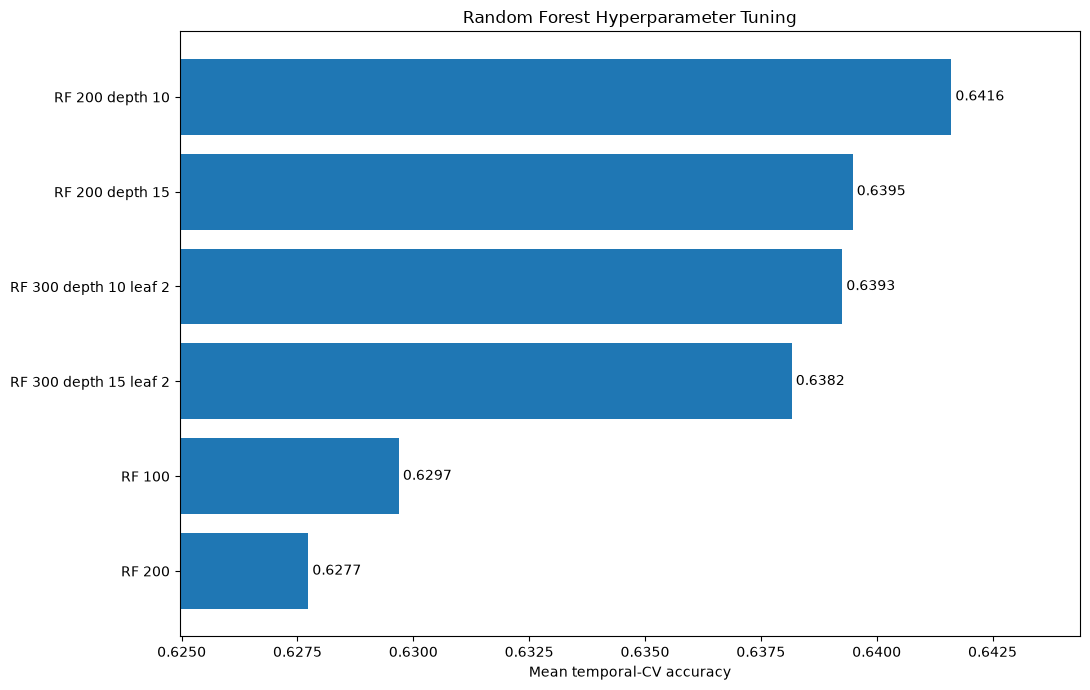

In [16]:
# sort configurations so that the plot goes from lowest to highest accuracy
plot_data = rf_cv_tuning_summary.sort_values(
    "MeanAccuracy",
    ascending=True
)

# find the range of observed accuracies
min_accuracy = plot_data["MeanAccuracy"].min()
max_accuracy = plot_data["MeanAccuracy"].max()

difference = max_accuracy - min_accuracy

# add a small amount of padding around the observed range so that the differences are easier to see
padding = max(
    difference*0.20,
    0.001
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    plot_data["Model"],
    plot_data["MeanAccuracy"]
)

plt.xlim(
    min_accuracy - padding,
    max_accuracy + padding
)

plt.xlabel("Mean temporal-CV accuracy")
plt.title("Random Forest Hyperparameter Tuning")

# display the exact accuracy value next to each bar
for bar, value in zip(
    bars,
    plot_data["MeanAccuracy"]
):

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Select the best Random Forest

The first configuration in the sorted summary is selected as the best Random Forest according to the temporal-CV results.

In [17]:
# select the configuration with the best temporal-CV performance
best_model_name = (rf_cv_tuning_summary.iloc[0]["Model"])
print("Selected Random Forest:", best_model_name)

Selected Random Forest: RF 200 depth 10


In [18]:
# retrieve the complete parameter dictionary of the selected model
best_configuration = next(
    configuration
    for configuration in configurations 
    if configuration["name"]== best_model_name
)

best_configuration

{'name': 'RF 200 depth 10',
 'n_estimators': 200,
 'max_depth': 10,
 'min_samples_leaf': 1}

## Fit preprocessing on all training data

Hyperparameter tuning is now finished.

We can therefore fit the preprocessing using the complete 2015–2022 training set.

The 2023 validation set is transformed using the same preprocessing objects, but it is not used to fit them.

In [19]:
# fit preprocessing using the complete training period
(
    numeric_medians,
    categorical_modes,
    one_hot_encoder
) = fit_preprocessor(
    train_data
)

# transform the complete training set
X_train = transform_data(
    train_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

# transform the external 2023 validation set using the same preprocessing
X_validation = transform_data(
    validation_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

# extract the target values
y_train = train_data["Player1Won"].to_numpy()
y_validation = validation_data["Player1Won"].to_numpy()

In [20]:
# check the dimensions of the training and validation data
print("Training X:", X_train.shape)
print("Validation X:", X_validation.shape)
print("Training y:", y_train.shape)
print("Validation y:", y_validation.shape)

# both datasets should have the same number of input features
assert X_train.shape[1] == 50
assert X_validation.shape[1] == 50

# preprocessing should not leave any missing values
assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0

print("Random Forest preprocessing check passed.")

Training X: (18810, 50)
Validation X: (2607, 50)
Training y: (18810,)
Validation y: (2607,)
Random Forest preprocessing check passed.


## Create the selected Random Forest

Now that the best configuration has been selected, we create the final Random Forest using those parameters.

This model will then be trained on the complete 2015–2022 training period.

In [21]:
# create the Random Forest using the selected hyperparameters
best_model = RandomForestClassifier(
    n_estimators=best_configuration["n_estimators"],
    max_depth=best_configuration["max_depth"],
    min_samples_leaf=best_configuration["min_samples_leaf"],
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

In [22]:
# train the selected configuration using the complete 2015-2022 model-development training period
best_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [23]:
# returns predicted classes [0, 1, 1, 0, 1, ...]
best_validation_predictions = (
    best_model.predict(X_validation)
) 
# 0 = player 2 wins
# 1 = player 1 wins

# returns probabilities that player 1 wins [0.23, 0.81, ...]
best_validation_probabilities = (
    best_model.predict_proba(X_validation)[:, 1]
) 

# compares the true validation labels with the predicted labels: display precision, recall and F1-score for both classes
print(
    classification_report(
        y_validation, 
        best_validation_predictions, 
        target_names=["Player 2 wins", "Player 1 wins"], 
        zero_division = 0
    ) 
)

               precision    recall  f1-score   support

Player 2 wins       0.66      0.64      0.65      1368
Player 1 wins       0.62      0.64      0.63      1239

     accuracy                           0.64      2607
    macro avg       0.64      0.64      0.64      2607
 weighted avg       0.64      0.64      0.64      2607



### Evaluate the selected Random Forest

The selected model is now evaluated on the external 2023 validation set.

The same evaluation function is used for the different classifiers so that their results can be compared consistently.

In [24]:
# calculate the main evaluation metrics for the external validation set
best_rf_result= evaluate_model(
    y_true=y_validation,
    y_pred=best_validation_predictions,
    model_name=best_model_name,
    y_probability=best_validation_probabilities
)

best_rf_result

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss
0,RF 200 depth 10,0.64135,0.641174,0.619122,0.637611,0.628231,0.703815,0.624294


### Confusion matrix

The confusion matrix shows how many matches were correctly and incorrectly classified for each outcome.

The two classes are:

- `0` → Player 2 wins
- `1` → Player 1 wins

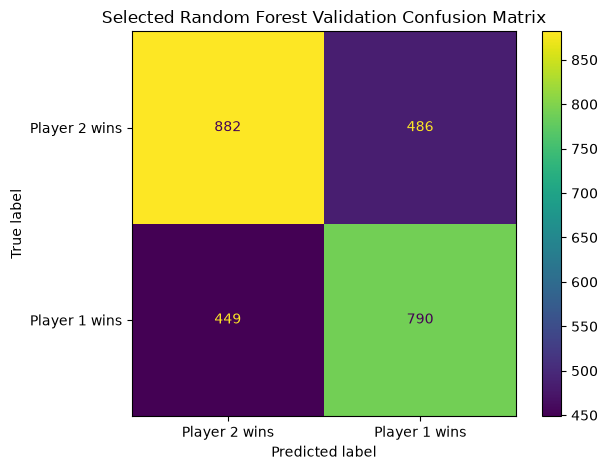

In [25]:
# display the confusion matrix for the 2023 validation predictions
ConfusionMatrixDisplay.from_predictions(
    y_validation, 
    best_validation_predictions,
    display_labels=[
        "Player 2 wins",
        "Player 1 wins"
    ],
    values_format="d"
)

plt.title("Selected Random Forest Validation Confusion Matrix")
plt.tight_layout()
plt.show()

## Feature importance

Random Forest provides an importance value for each input feature.

This allows us to investigate which features are used most by the model when predicting the match outcome.

In particular, we can see whether the historical features created during feature engineering are among the most useful variables.

In [26]:
# create a dataframe with the feature importance values
# X_train.columns contains the final feature names after preprocessing, including both:
# - numerical features
# - one-hot encoded categorical features

rf_feature_importance = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_ # assigns an importance value to each input feature
        # importance values show how much each feature contributes to the decisions made by the forest
        # the values add approximately to 1
    }
)

# order the features from most important to least important
rf_feature_importance = (
    rf_feature_importance.sort_values(
        by="Importance", ascending=False
    ).reset_index(drop=True)
)

rf_feature_importance

,Feature,Importance
0,PointsDifference,0.125788
1,RankDifference,0.097723
2,WinRateDifference,0.081795
3,SurfaceWinRateDifference,0.063267
4,Player2Points,0.047606
5,Player1Points,0.046803
6,Player1Rank,0.043834
7,Player2Rank,0.041618
8,SurfaceMatchesDifference,0.038916
9,ExperienceDifference,0.036477


In [27]:
# check that every model feature has one corresponding importance value
print("Number of model features:", X_train.shape[1])
print("Number of feature importances:", len(best_model.feature_importances_))

assert(len(rf_feature_importance) == X_train.shape[1])
print("Feature importance check passed.")

Number of model features: 50
Number of feature importances: 50
Feature importance check passed.


## Save the results

The main results of the Random Forest experiment are saved so that they can be reused later without running the complete cross-validation again.

We save the cross-validation results, the final validation result and the feature importance values.

In [28]:
# folders used to store the different Random Forest outputs
MODEL_SELECTION_RESULTS_DIR = Path(
    "../results/model_selection"
)

VALIDATION_RESULTS_DIR = Path(
    "../results/validation"
)

FEATURE_IMPORTANCE_RESULTS_DIR = Path(
    "../results/feature_importance"
)

MODELS_DIR = Path("../models")

# save the results of every temporal-CV fold
rf_cv_fold_results.to_csv(
    MODEL_SELECTION_RESULTS_DIR / "rf_cv_fold_results.csv", index=False
)

# save the summary used to compare the configurations
rf_cv_tuning_summary.to_csv(
    MODEL_SELECTION_RESULTS_DIR / "rf_cv_tuning_summary.csv", index=False
)

# save the feature importance values
rf_feature_importance.to_csv(
    FEATURE_IMPORTANCE_RESULTS_DIR / "rf_feature_importance.csv", index=False
)

# save the final validation metrics
best_rf_result.to_csv(
    VALIDATION_RESULTS_DIR / "best_rf_result.csv", index=False
)

In [29]:
# joblib is used to save the trained model and preprocessing objects
import joblib 

# save the trained Random Forest
joblib.dump(best_model, MODELS_DIR / "best_rf_validation.joblib")

# store all preprocessing information needed to transform new data
rf_preprocessing = {
    "numeric_medians": numeric_medians,
    "categorical_modes": categorical_modes,
    "one_hot_encoder": one_hot_encoder
}

# save the preprocessing separately from the model
joblib.dump(
    rf_preprocessing,
    MODELS_DIR/"rf_preprocessing.joblib"
)

['..\\models\\rf_preprocessing.joblib']

## Final Random Forest summary

The final output shows the temporal cross-validation results, the selected Random Forest configuration and its performance on the external 2023 validation set.

In [30]:
# final summary of the Random Forest experiment
print("Random Forest Temporal CV")

print(rf_cv_tuning_summary)

print(
    "\nSelected Random Forest:",
    best_model_name
)

print("\nExternal 2023 validation")
print(best_rf_result)

Random Forest Temporal CV
                    Model  MeanAccuracy  StdAccuracy  MeanBalancedAccuracy  \
0         RF 200 depth 10      0.641612     0.015238              0.641649   
1         RF 200 depth 15      0.639484     0.014980              0.639569   
2  RF 300 depth 10 leaf 2      0.639258     0.011782              0.639344   
3  RF 300 depth 15 leaf 2      0.638168     0.013094              0.638338   
4                  RF 100      0.629689     0.017209              0.629844   
5                  RF 200      0.627734     0.015754              0.627796   

   MeanF1Score  MeanROC_AUC  MeanLogLoss  
0     0.623721     0.702230     0.624893  
1     0.625950     0.694884     0.629909  
2     0.622160     0.703647     0.623535  
3     0.623833     0.697278     0.628350  
4     0.612559     0.682588     0.637232  
5     0.614992     0.685168     0.635369  

Selected Random Forest: RF 200 depth 10

External 2023 validation
             Model  Accuracy  BalancedAccuracy  Precision  

In [31]:
# display the 15 most important features according to the selected model
print("Top 15 features:")
print(rf_feature_importance.head(15))

Top 15 features:
                        Feature  Importance
0              PointsDifference    0.125788
1                RankDifference    0.097723
2             WinRateDifference    0.081795
3      SurfaceWinRateDifference    0.063267
4                 Player2Points    0.047606
5                 Player1Points    0.046803
6                   Player1Rank    0.043834
7                   Player2Rank    0.041618
8      SurfaceMatchesDifference    0.038916
9          ExperienceDifference    0.036477
10         Player1WinRateBefore    0.035744
11         Player2WinRateBefore    0.032757
12  Player2SurfaceWinRateBefore    0.031553
13  Player1SurfaceWinRateBefore    0.030174
14         Player2MatchesBefore    0.024788
